/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting Model Training...
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6783 - loss: 0.9101 - val_accuracy: 1.0000 - val_loss: 0.5848
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9996 - loss: 0.2713 - val_accuracy: 1.0000 - val_loss: 0.0938
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0502 - val_accuracy: 1.0000 - val_loss: 0.0252
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0142 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss

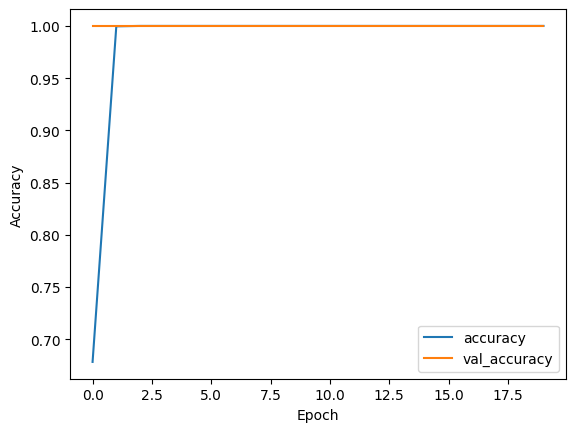

Saved artifact at '/tmp/tmp1g6ogcul'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133972955014992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133972955016144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133972955014800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133972955013456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133972955016720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133972955013648: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model Trained & Exported: color_reco_model.tflite


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. GENERATE SYNTHETIC DATASET (10,000 pairings based on Design Rules)
# Rules: 0=Modern(Grey/Blue), 1=Warm(Terracotta/Beige), 2=Calm(SkyBlue/Green)
def generate_data(num_samples=10000):
    data = []
    for _ in range(num_samples):
        mood = np.random.randint(0, 3) # 0, 1, or 2
        if mood == 0: # Modern
            color = [0.2, 0.3, 0.5] + np.random.normal(0, 0.05, 3) # Slate Blue-ish
        elif mood == 1: # Warm
            color = [0.8, 0.5, 0.3] + np.random.normal(0, 0.05, 3) # Warm Earth
        else: # Calm
            color = [0.5, 0.8, 0.9] + np.random.normal(0, 0.05, 3) # Sky Blue
        data.append(list(color.clip(0,1)) + [mood])
    return pd.DataFrame(data, columns=['R', 'G', 'B', 'Mood'])

df = generate_data()
X = df[['R', 'G', 'B']].values
y = df['Mood'].values

# 2. BUILD THE NEURAL NETWORK (MLP)
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(3,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax') # 3 Mood Categories
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. TRAIN THE MODEL
print("Starting Model Training...")
history = model.fit(X, y, epochs=20, validation_split=0.2, batch_size=32)

# 4. PLOT ACCURACY
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# 5. EXPORT TO TFLITE (FOR FLUTTER APP)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('color_reco_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model Trained & Exported: color_reco_model.tflite")
